In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None
import warnings

In [50]:
test =pd.read_csv('/kaggle/input/world-championship-2023-embryo-classification/hvwc23/test.csv')
test.head() 

,ID,Image
0,1,D3_693.jpg
1,2,D3_212.jpg
2,3,D3_724.jpg
3,4,D3_623.jpg
4,5,D3_210.jpg


In [51]:
train = pd.read_csv('/kaggle/input/world-championship-2023-embryo-classification/hvwc23/train.csv')
train.head()

,Image,Class
0,D3_405.jpg,0
1,D3_523.jpg,0
2,D3_750.jpg,0
3,D3_427.jpg,0
4,D3_042.jpg,0


In [52]:
combined = pd.concat([test,train])
combined.head()

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,ID,Image,Class
0,1.0,D3_693.jpg,NaN
1,2.0,D3_212.jpg,NaN
2,3.0,D3_724.jpg,NaN
3,4.0,D3_623.jpg,NaN
4,5.0,D3_210.jpg,NaN


In [5]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1020 entries, 0 to 179
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Image   1020 non-null   object 
 1   Class   840 non-null    float64
 2   ID      180 non-null    float64
dtypes: float64(2), object(1)
memory usage: 31.9+ KB


In [6]:
combined.dtypes

Image     object
Class    float64
ID       float64
dtype: object

In [7]:
combined.columns

Index(['Image', 'Class', 'ID'], dtype='object')

In [8]:
combined.isnull().sum()/len(combined)*100

Image     0.000000
Class    17.647059
ID       82.352941
dtype: float64

In [9]:
combined.shape

(1020, 3)

In [10]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
Class,840.0,0.147619,0.354933,0.0,0.00,0.0,0.00,1.0
ID,180.0,90.500000,52.105662,1.0,45.75,90.5,135.25,180.0


<Axes: >

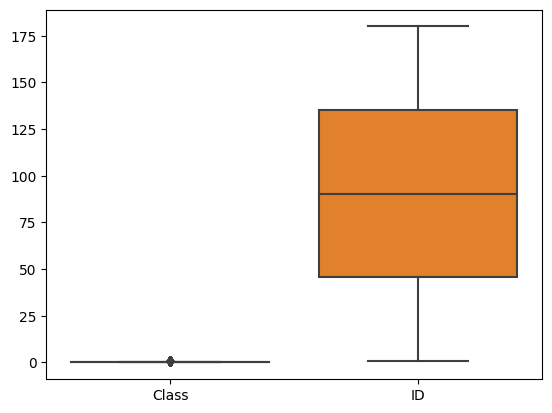

In [11]:
sns.boxplot(combined)

<Axes: >

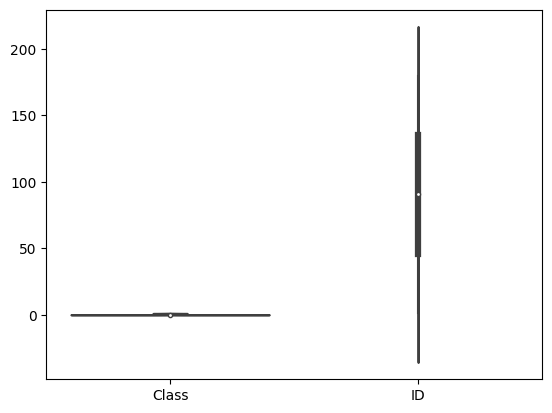

In [12]:
sns.violinplot(combined)

<Axes: >

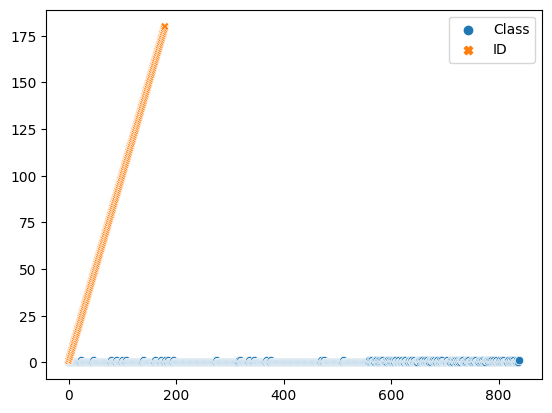

In [13]:
sns.scatterplot(combined)

<Axes: >

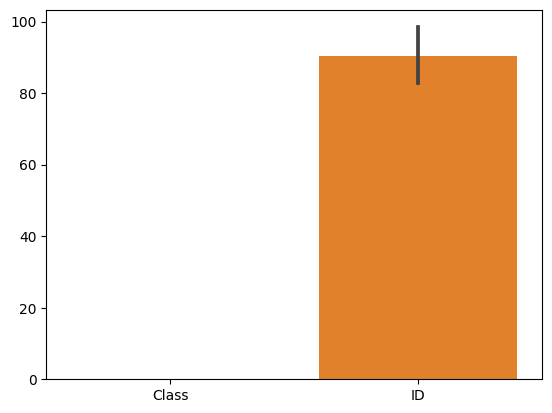

In [14]:
sns.barplot(combined)

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: >

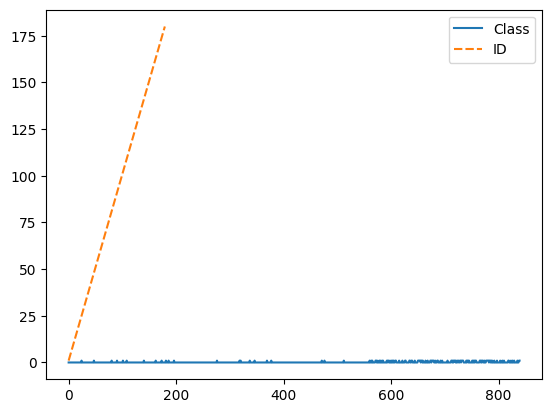

In [15]:
sns.lineplot(combined)

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


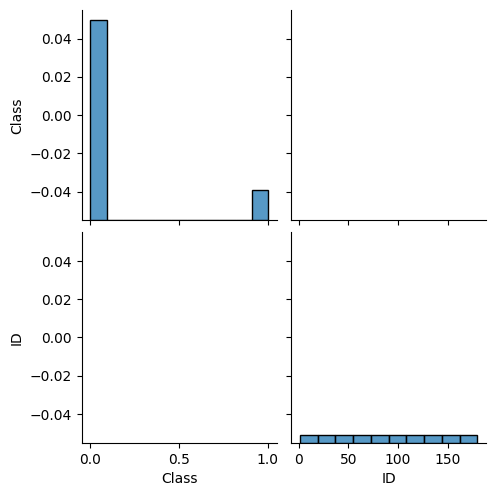

In [16]:
sns.pairplot(combined)

In [17]:
combined.skew

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


<bound method DataFrame.skew of           Image  Class     ID
0    D3_405.jpg    0.0    NaN
1    D3_523.jpg    0.0    NaN
2    D3_750.jpg    0.0    NaN
3    D3_427.jpg    0.0    NaN
4    D3_042.jpg    0.0    NaN
..          ...    ...    ...
175  D5_020.jpg    NaN  176.0
176  D5_133.jpg    NaN  177.0
177  D5_119.jpg    NaN  178.0
178  D5_322.jpg    NaN  179.0
179  D5_017.jpg    NaN  180.0

[1020 rows x 3 columns]>

In [18]:
combined.kurt

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


<bound method DataFrame.kurt of           Image  Class     ID
0    D3_405.jpg    0.0    NaN
1    D3_523.jpg    0.0    NaN
2    D3_750.jpg    0.0    NaN
3    D3_427.jpg    0.0    NaN
4    D3_042.jpg    0.0    NaN
..          ...    ...    ...
175  D5_020.jpg    NaN  176.0
176  D5_133.jpg    NaN  177.0
177  D5_119.jpg    NaN  178.0
178  D5_322.jpg    NaN  179.0
179  D5_017.jpg    NaN  180.0

[1020 rows x 3 columns]>

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

<Axes: ylabel='Density'>

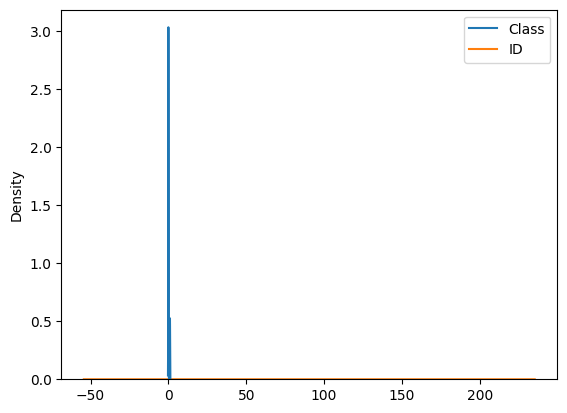

In [19]:
sns.kdeplot(combined)

In [22]:
cat_cols = combined.select_dtypes(include='object')

In [23]:
for i in cat_cols:
    print(combined[i].value_counts())
    print(i)
    print(''*100)

Image
D3_405.jpg    1
D5_084.jpg    1
D5_238.jpg    1
D5_027.jpg    1
D5_121.jpg    1
             ..
D3_187.jpg    1
D3_124.jpg    1
D3_684.jpg    1
D3_144.jpg    1
D5_017.jpg    1
Name: count, Length: 1020, dtype: int64
Image



In [24]:
num_cols = combined.select_dtypes(include='number')

In [25]:
for i in num_cols:
    print(combined[i].value_counts())
    print(i)
    print(''*100)

Class
0.0    716
1.0    124
Name: count, dtype: int64
Class

ID
1.0      1
114.0    1
116.0    1
117.0    1
118.0    1
        ..
62.0     1
63.0     1
64.0     1
65.0     1
180.0    1
Name: count, Length: 180, dtype: int64
ID



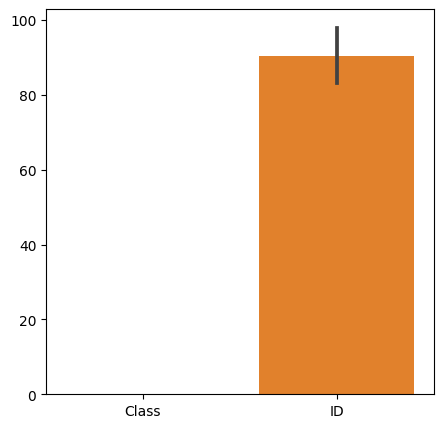

In [26]:
x=1
plt.figure(figsize=(5,5))
for i in cat_cols:
    sns.barplot(data=combined)
    print('\n')
    plt.show()

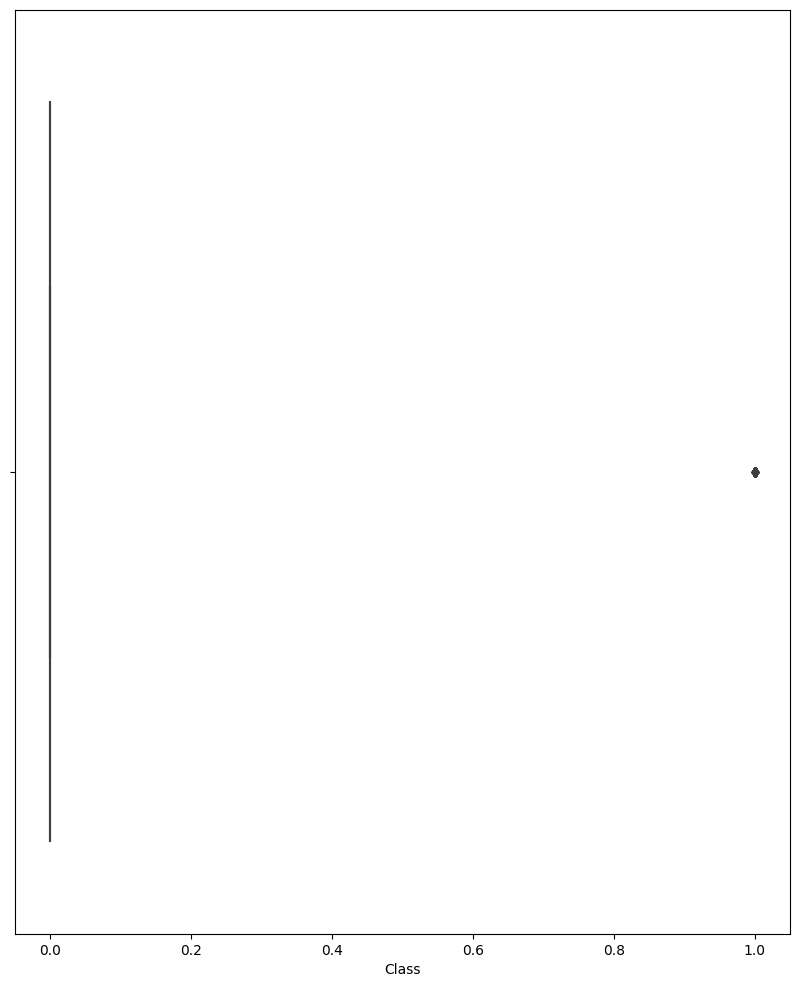

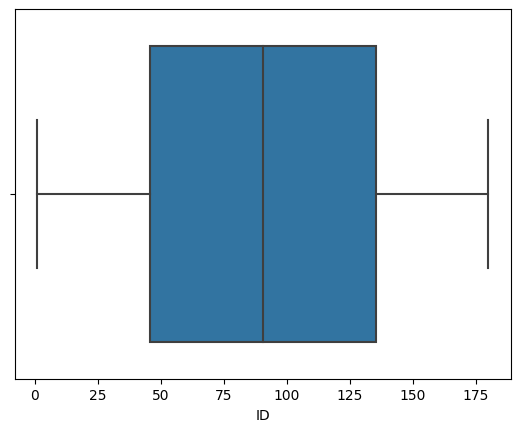

In [27]:
x=1
plt.figure(figsize=(10,12))
for i in num_cols:
    sns.boxplot(data=combined,x=i)
    print('\n')
    plt.show()

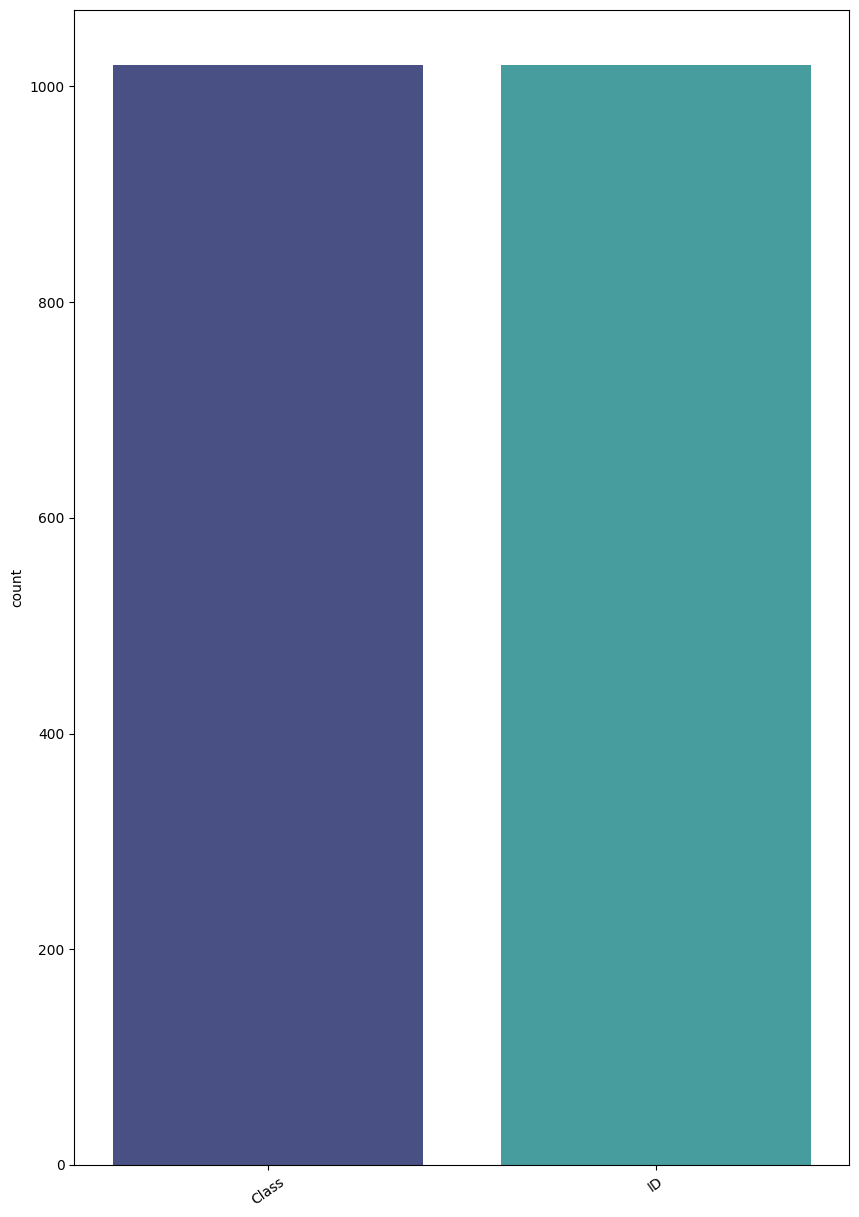

In [28]:
plt.figure(figsize=(10,15))
sns.countplot(combined,palette='mako');
plt.xticks(rotation=35); 

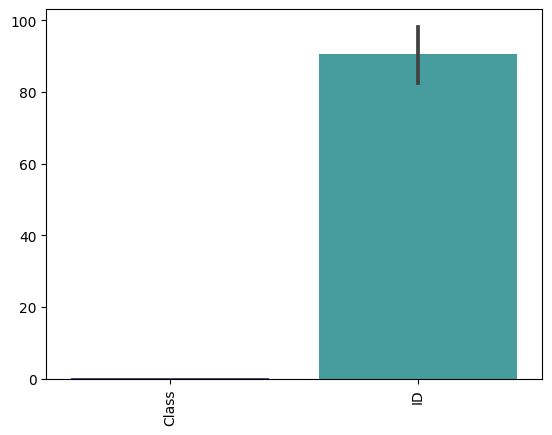

In [29]:
sns.barplot(combined,palette='mako');
plt.xticks(rotation=90);

(array([0, 1]), [Text(0, 0, 'Class'), Text(1, 0, 'ID')])

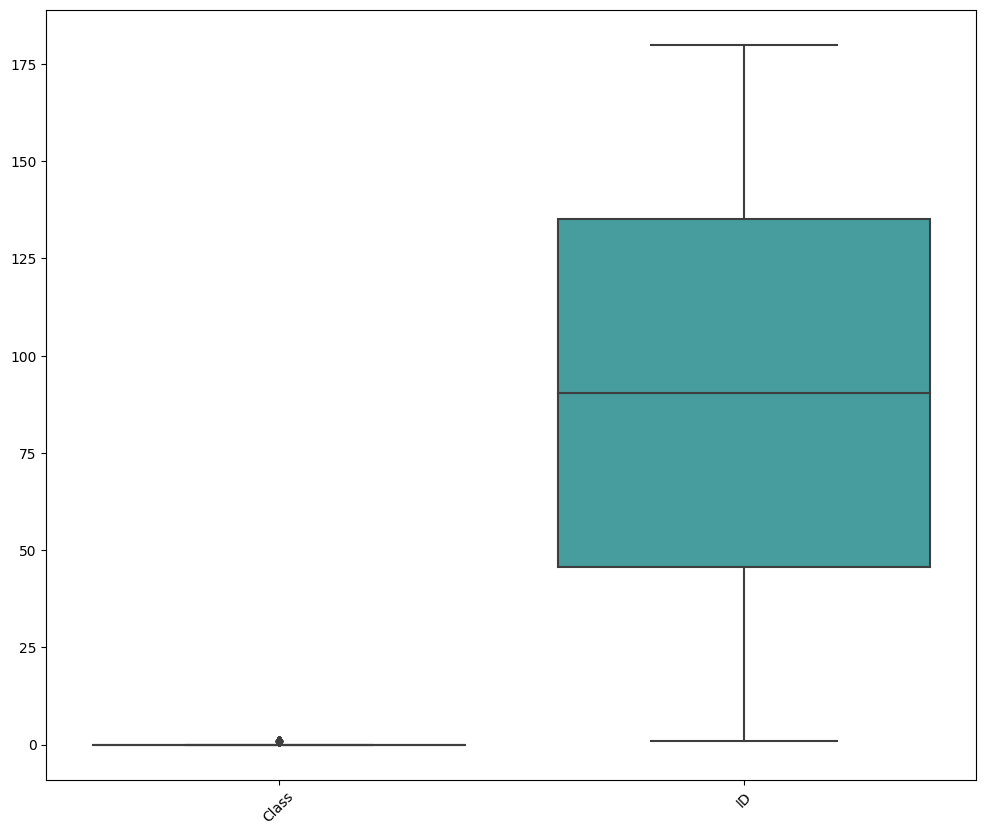

In [30]:
plt.figure(figsize=(12,10))
sns.boxplot(combined,palette='mako');
plt.xticks(rotation=45)

<Axes: ylabel='count'>

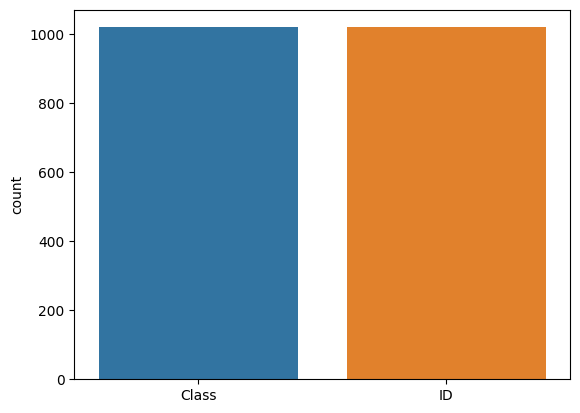

In [31]:
sns.countplot(combined)

In [53]:
combined.head()

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,ID,Image,Class
0,1.0,D3_693.jpg,NaN
1,2.0,D3_212.jpg,NaN
2,3.0,D3_724.jpg,NaN
3,4.0,D3_623.jpg,NaN
4,5.0,D3_210.jpg,NaN


In [54]:
x = combined[['ID']]

In [55]:
y = combined[['ID']]

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3)

In [58]:
from sklearn.linear_model import LinearRegression

In [59]:
lr = LinearRegression()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


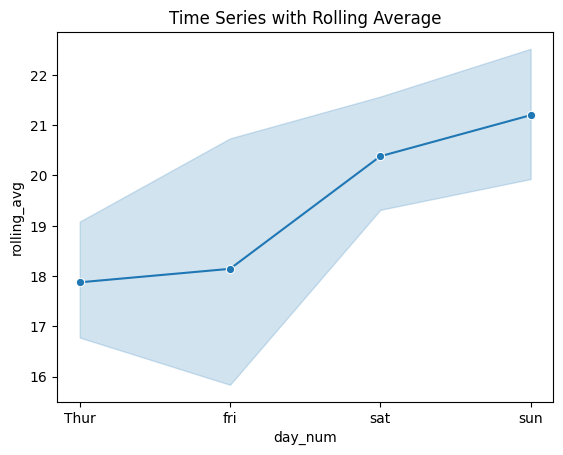

In [48]:
df_tips = sns.load_dataset('tips')
df_tips['day_num'] = df_tips['day'].astype('category').cat.codes

df_tips['rolling_avg'] = df_tips['total_bill'].rolling(window=3).mean()

sns.lineplot(x='day_num', y='rolling_avg',data=df_tips,marker='o')
plt.xticks(ticks=[0,1,2,3], labels=['Thur','fri','sat','sun'])
plt.title("Time Series with Rolling Average")
plt.show()